In [ ]:
!pip install -q git+https://github.com/THU-MIG/yolov10.git

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
!wget -P -q https://github.com/jameslahm/yolov10/releases/download/v1.0/yolov10n.pt

--2025-09-27 05:18:59--  https://github.com/jameslahm/yolov10/releases/download/v1.0/yolov10n.pt
Resolving github.com (github.com)... 140.82.121.4
Connecting to github.com (github.com)|140.82.121.4|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://github.com/THU-MIG/yolov10/releases/download/v1.0/yolov10n.pt [following]
--2025-09-27 05:18:59--  https://github.com/THU-MIG/yolov10/releases/download/v1.0/yolov10n.pt
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/804788522/de01476f-8157-4901-921f-e0c6cb3848cf?sp=r&sv=2018-11-09&sr=b&spr=https&se=2025-09-27T06%3A07%3A25Z&rscd=attachment%3B+filename%3Dyolov10n.pt&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2025-09-27T05%3A07%3A22Z&ske=2025-09-27T06%3A07%3A25Z&sks=b&skv=2018-11-09&si

In [ ]:
!pip install -q roboflow

In [ ]:
from roboflow import Roboflow
rf = Roboflow(api_key = "6HTmCXrvTuYMc6AG2msQ")
project = rf.workspace("brain-mri").project("mri-rskcu")
version = project.version(3)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...


In [ ]:
!pip install ultralytics


In [ ]:


# Install stable PyTorch + TorchVision that match
!pip install torch==2.3.1 torchvision==0.18.1 torchaudio==2.3.1 --index-url https://download.pytorch.org/whl/cu121


Looking in indexes: https://download.pytorch.org/whl/cu121


In [ ]:
!pip install ultralytics --upgrade


  Using cached ultralytics-8.3.203-py3-none-any.whl.metadata (37 kB)
Using cached ultralytics-8.3.203-py3-none-any.whl (1.1 MB)
  Attempting uninstall: ultralytics
    Found existing installation: ultralytics 8.1.34
    Uninstalling ultralytics-8.1.34:
      Successfully uninstalled ultralytics-8.1.34


In [ ]:
!yolo task=detect mode=train epochs=25 batch=32 plots=True \
model=yolov10n.pt \
data=/content/MRI-3/data.yaml


Ultralytics 8.3.203 🚀 Python-3.12.11 torch-2.3.1+cu121 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/MRI-3/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov10n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.

In [ ]:
from ultralytics import YOLO

# Load your trained model
model_path = "/content/runs/detect/train/weights/best.pt"
model = YOLO(model_path)

# Run inference
results = model.predict(
    source="/content/MRI-3/valid/images",  # folder of images
    conf=0.25,
    save=True
)



image 1/151 /content/MRI-3/valid/images/Tr-glTr_0000_jpg.rf.ee4ad3ca5d0eafd1f482988b89457634.jpg: 640x640 1 Brain-Tumor, 11.7ms
image 2/151 /content/MRI-3/valid/images/Tr-gl_0021_jpg.rf.82e37d9cdf73ab894e8af3cd4bfb70a8.jpg: 640x640 2 Brain-Tumors, 11.4ms
image 3/151 /content/MRI-3/valid/images/Tr-gl_0119_jpg.rf.0768b25ee8d4e0aa20df53673dce853e.jpg: 640x640 1 Brain-Tumor, 9.4ms
image 4/151 /content/MRI-3/valid/images/Tr-gl_0228_jpg.rf.b9ecef834d39f770e41b0585b63bdc1a.jpg: 640x640 2 Brain-Tumors, 9.4ms
image 5/151 /content/MRI-3/valid/images/Tr-gl_0342_jpg.rf.10e62693351dae5f8b8f0e136c8ec8c3.jpg: 640x640 1 Brain-Tumor, 1 eye, 9.0ms
image 6/151 /content/MRI-3/valid/images/Tr-gl_0493_jpg.rf.4393a755ad877b333ee635f7d8625687.jpg: 640x640 1 Brain-Tumor, 9.2ms
image 7/151 /content/MRI-3/valid/images/Tr-gl_0565_jpg.rf.4975825d65539d7d35caf0f61517f236.jpg: 640x640 1 Brain-Tumor, 12.4ms
image 8/151 /content/MRI-3/valid/images/Tr-gl_0585_jpg.rf.eeb0b7c0f19a6763494b9e53fee546db.jpg: 640x640 1 Brai

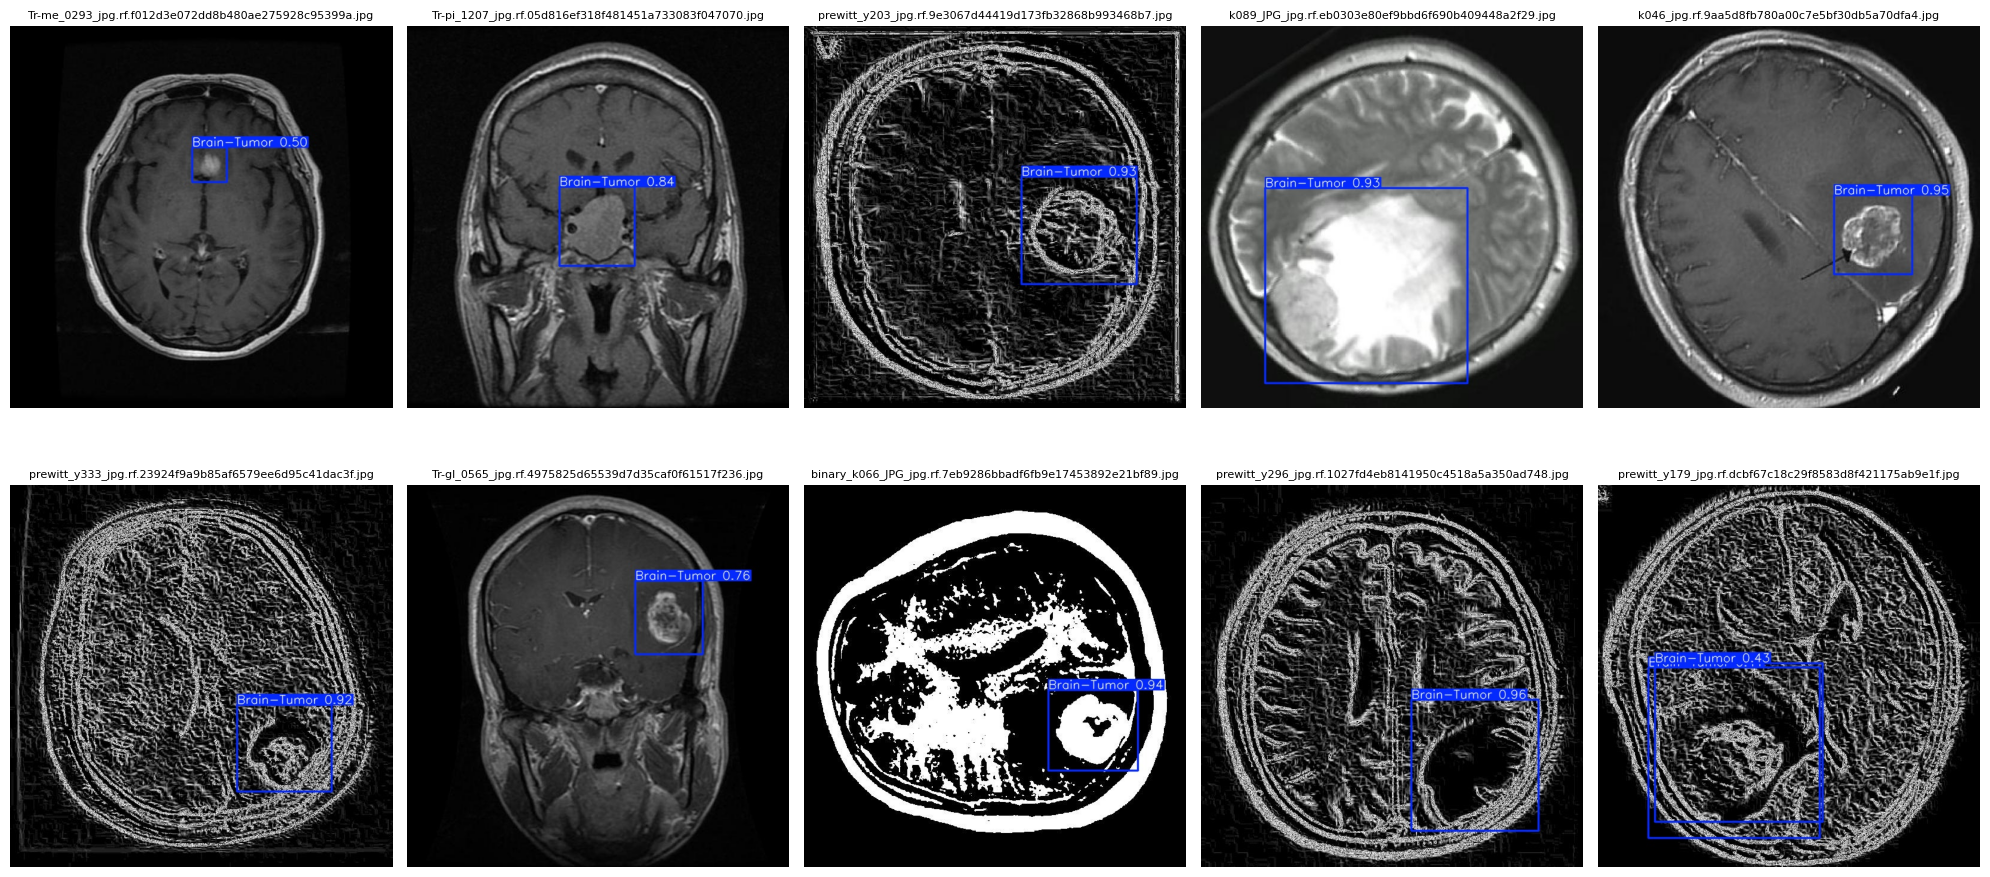

In [ ]:
import glob
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Get all predicted images (JPG + PNG)
images = glob.glob("/content/runs/detect/predict/*.jpg") + glob.glob("/content/runs/detect/predict/*.png")
images_to_display = images[:10]  # pick first 10

fig, axes = plt.subplots(2, 5, figsize=(20, 10))

for i, ax in enumerate(axes.flat):
    if i < len(images_to_display):
        img = mpimg.imread(images_to_display[i])
        ax.imshow(img)
        ax.set_title(images_to_display[i].split("/")[-1], fontsize=8)
        ax.axis("off")
    else:
        ax.axis("off")

plt.tight_layout()
plt.show()



image 1/1 /content/MRI-3/valid/images/Tr-glTr_0000_jpg.rf.ee4ad3ca5d0eafd1f482988b89457634.jpg: 640x640 1 Brain-Tumor, 19.2ms
Speed: 7.3ms preprocess, 19.2ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 640)


array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], dtype=uint8)
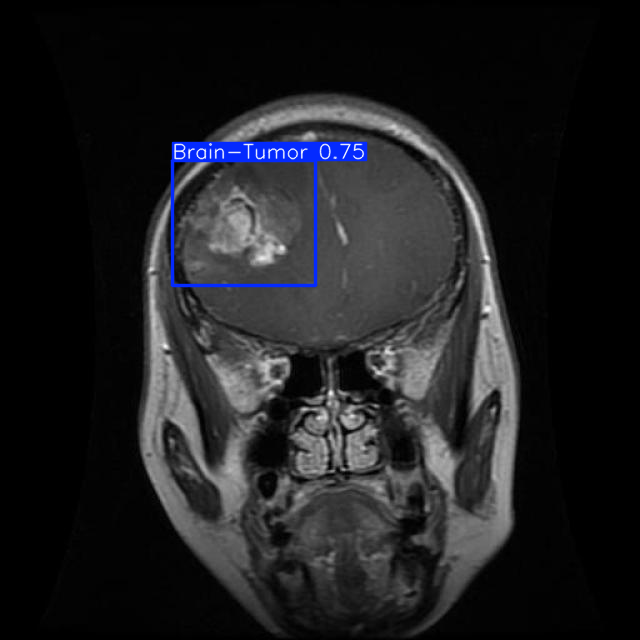

In [ ]:
result = model.predict(source = "/content/MRI-3/valid/images/Tr-glTr_0000_jpg.rf.ee4ad3ca5d0eafd1f482988b89457634.jpg", imgsz = 640, conf = 0.25)
annotated_img = result[0].plot()
annotated_img[:, :, ::-1]